In [39]:
from sage.matrix.constructor import Matrix
from sage.rings.rational_field import QQ

class bMatrix:
    def __init__(self, dim:tuple, position):
        """
        Initializes a matrix of size (nrows x ncols) with a single entry of 1 at 'position'.
        
        :param nrows: Number of rows
        :param ncols: Number of columns
        :param position: A tuple (i, j) specifying the position of the 1-entry
        """
        nrows=dim[0]
        ncols=dim[1]
        # Create a zero matrix first
        self.mat = Matrix(QQ, nrows, ncols, 0)
        
        # Ensure position is within bounds
        if len(position)>0:
            if not (0 <= position[0] < nrows and 0 <= position[1] < ncols):
                raise ValueError("Position is out of bounds.")
            
            # Set the single 1-entry
            self.mat[position] = 1

    def is_valid(self):
        """
        Checks if the matrix has exactly one entry as 1 and all others are 0.
        """
        return sum(self.mat.list()) == 1  # Sum of entries should be exactly 1

    def __mul__(self, other):
        """
        Defines the multiplication operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat * other.mat
        else:
            raise TypeError("Unsupported operand type(s) for *: 'OneEntryMatrix' and '{}'".format(type(other).__name__))
    def __add__(self, other):
        """
        Defines the addition operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat + other.mat
        else:
            raise TypeError("Unsupported operand type(s) for +: 'OneEntryMatrix' and '{}'".format(type(other).__name__))
    def __sub__(self, other):
        """
        Defines the subtraction operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat - other.mat
        else:
            raise TypeError("Unsupported operand type(s) for -: 'OneEntryMatrix' and '{}'".format(type(other).__name__))
    def __eq__(self, other):
        """
        Defines the equality operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat == other.mat
        else:
            raise TypeError("Unsupported operand type(s) for ==: 'OneEntryMatrix' and '{}'".format(type(other).__name__))

    def __repr__(self):
        return repr(self.mat)


# Graph Magma Class 

In [40]:
class graphMagma:
    from sage.matrix.constructor import block_matrix, zero_matrix, identity_matrix, matrix
    from sage.rings.integer_ring import ZZ
    from sage.all import var
    
    #Create a global variable to store the generators
    generators = []
    Inc = matrix(ZZ, 0, 0, [])
    multiplication_table = matrix(SR,0,0,[])
    #Create a global variable to store the graph
    graph = []
    def __init__(self, graph:list):
        self.graph = graph
        self.generators = self.getGenerators()
        self.Inc = self.getIncidenceMatrix()
        self.multiplication_table = self.getMultiplicationTable()
    def getGenerators(self):
        self.generators = []
        for i in range(len(self.graph)):
            for j in range(self.graph[i][1]):
                self.generators.append(var(f"a_{i}_{j}", latex_name=fr"\alpha_{{{i},{j}}}"))
        return self.generators
    def getGraph(self):
        return self.graph
    def incidenceMatrix(self):
        G=self.graph
        I=self.Inc
        for g in G:
            if g[0] == 'K':
                I = block_matrix([[I, matrix(I.nrows(), g[1],[1]*(I.nrows()*g[1]))], [zero_matrix(g[1], I.ncols()), matrix(g[1], g[1], [1]*(g[1]*g[1]))]])
            else:
                I = block_matrix([[I, matrix(I.nrows(), g[1],[1]*(I.nrows()*g[1]))], [zero_matrix(g[1], I.ncols()), matrix(g[1],g[1])]])  
        self.Inc = I
    def getIncidenceMatrix(self):
        self.incidenceMatrix()
        return self.Inc  
    def multiplicationTable(self):
        I=self.Inc
        M=matrix(SR,I.nrows(),I.nrows())
        self.getGenerators()
        for i in range(I.nrows()):
            for j in range(I.nrows()):
                if I[i,j]==0:
                    M[i,j]=self.generators[j]
                else:
                    M[i,j]=self.generators[i]
        self.multiplication_table = M
    def getMultiplicationTable(self):
        self.multiplicationTable()
        return self.multiplication_table

# Graph Magma Algebra Class

In [41]:
from sage.algebras.free_algebra import FreeAlgebra
from sage.algebras.free_algebra_quotient import FreeAlgebraQuotient
from sage.structure.element import Element
from random import choice
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
relations=[]
class GraphMagmaAlg:
    """
    This class implements the graph magma algebra.
    It is a quotient of the free algebra over the base ring.
    The generators are the elements of the graph.
    The relations are given by the incidence matrix of the graph.

    The attributes of the class are:
    - base_ring: the base ring of the algebra
    - generators: the generators of the algebra
    - graph: the graph of the algebra
    - multiplication_table: the multiplication table of the algebra
    - magma_algebra: the quotient of the free algebra
    - gens: the generators of the quotient algebra
    - local_decomposition: the generators of cyclic left local projective ideals in the indecomposable decomposition of the graph magma algebra
    - simple_left_ideals: the simple left ideals of local projective components of the graph magma algebra
    - relations: the relations of the algebra induced by the incidence matrix of the graph
    - Indecomposable_Injective: the indecomposable injective left modules over the graph magma algebra indexed by the local projective components of the graph
    """
    def __init__(self,base_ring,GM:graphMagma):
        R=FreeAlgebraQuotient
        self.base_ring=base_ring
        self.generators=GM.getGenerators()
        self.generators_str=[str(g) for g in self.generators]
        self.graph=GM.getGraph()
        self.multiplication_table=GM.getMultiplicationTable()
        # Determine the number of generators from the list
        n = len(self.generators)
        # Create a string for the generator names
        generator_names_str =', '.join(self.generators_str)
        # Create the FreeAlgebra instance
        A = FreeAlgebra(base_ring, n,generator_names_str)
        self.alg=A
        F=A.monoid() #generator_names_str=F.gens();print(F.gens())
        self.mons=[F(1)]+list(F.gens())
        self.mats=self.build_relations()
        self.magma_algebra=FreeAlgebraQuotient(A, self.mons, self.mats, names=self.generators_str)
        splt=[g[1] for g in self.graph]
        L=self.magma_algebra.gens()
        self.gens=self.split_list(list(L),list(splt))
        self.magma_algebra.generators_dict={}
        self.magma_algebra.generators=self.split_list(list(self.magma_algebra.gens()),list(splt))
        for i in range(len(self.generators_str)):
            self.magma_algebra.generators_dict[self.generators_str[i]]=flatten(self.magma_algebra.generators)[i]
        self.local_decomposition=self.getDecomposition()
        self.simple_left_ideals=[self.getSimpleLeftIdeals(i) for i in range(len(self.graph)+1)]
        self.simple_right_ideals=[self.getSimpleRightIdeals(i) for i in range(len(self.graph)+1)]
        self.Jacobson_radical=self.__get_Jacobson_radical()
        self.right_singular_ideal=None
        self.left_singular_ideal=None
        self.quiver=self.__get_Quiver()
        
        #self.magma_algebra.multiplication_table=self.getMultiplicationTable(return_table=True)
    
    def __contains__(self, item):
        return item in self.magma_algebra
    
    def __str__(self):
        return f"GraphMagmaAlg with generators {list(self.generators_str)}"
    def __repr__(self):
        return f"GraphMagmaAlg with generators {list(self.generators_str)}"
    

    def build_relations(self):
        act=[];L=[];idx=0
        n=len(self.generators)
        self.relations=[];M=MatrixSpace(self.base_ring,n+1);I=identity_matrix(n+1)
        T=self.multiplication_table
        for j in range(T.nrows()):
            L=list(I[j+1])
            for i in range(T.ncols()):
                idx=self.generators.index(T[i,j])
                L+=list(I[idx+1])
            act.append(M(L))
        return act
            
    def split_list(self,L, lengths):
        result = []
        index = 0
        for length in lengths:
            sublist = L[index:index + length]
            result.append(sublist)
            index += length
        return result

    def getDecomposition(self):
        R=self.magma_algebra;g=self.gens
        L=[R(f[0]) for f in g]
        ideal_generators=[L[0]]+[L[i]-L[i-1] for i in [1..len(L)-1]]+[R(1)-L[-1]]
        return ideal_generators
    
    def getSimpleRightIdeals(self,n:int):
        '''This function gives the generators of the simple right ideals in a particular local projective component.
        n represents the index of the local projective component.     '''
        R=self.magma_algebra;G=self.graph;L=self.magma_algebra.generators
        if n==0:
            if G[0][0]=='N' and len(L[0])>1:
                return [L[0][i]-L[0][0] for i in range(1,len(L[0]))]
            else:
                return [L[0][0]]
        else:
            if n<len(G):
                sub_graph=G[n-1:n+1]
                if sub_graph[0][0]=='K' and sub_graph[1][0]=='K': # (K,K)
                    if sub_graph[0][1]==1:
                        return [L[n][0]-L[n-1][0]]
                    else:
                        return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
                elif sub_graph[0][0]=='K' and sub_graph[1][0]=='N': # (K,N)
                    if sub_graph[0][1]==1 and sub_graph[1][1]==1:
                        return [L[n][0]-L[n-1][0]]
                    else:
                        return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1])) if len(L[n-1])>1]+[L[n][0]-L[n][i] for i in range(1,len(L[n])) if len(L[n])>1]
                elif sub_graph[0][0]=="N" and sub_graph[1][0]=="K": # (N,K)
                    return [L[n][0]-L[n-1][0]]
                elif sub_graph[0][0]=="N" and sub_graph[1][0]=="N": # (N,N)
                    if sub_graph[1][1]==1:
                        return [L[n][0]-L[n-1][0]]
                    else:
                        return [L[n][0]-L[n][i] for i in range(1,len(L[n]))]
            else:
                if G[n-1][0]=='K' and len(L[n-1])>1:
                    return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
                else:
                    return [1-L[n-1][0]]

    def getSimpleLeftIdeals(self,n:int):
        '''This function gives the generators of the simple left ideals in a particular local projective component.
        n represents the index of the local projective component.     '''
        R=self.magma_algebra;G=self.graph;L=self.gens
        if n==0:
            if G[0][0]=='K' and len(L[0])>1:
                return [L[0][i]-L[0][0] for i in range(1,len(L[0]))]
            else:
                return [L[0][0]]
        else:
            if n<len(G):
                sub_graph=G[n-1:n+1]
                if sub_graph[0][0]=='K' and sub_graph[1][0]=='K': # (K,K)
                    if sub_graph[1][1]==1:
                        return [L[n][0]-L[n-1][0]]
                    else:
                        return [L[n][0]-L[n][i] for i in range(1,len(L[n]))]
                elif sub_graph[0][0]=='K' and sub_graph[1][0]=='N': # (K,N)
                    return [L[n][0]-L[n-1][0]]
                elif sub_graph[0][0]=='N' and sub_graph[1][0]=='K': # (N,K)
                    if sub_graph[0][1]==1 and sub_graph[1][1]==1:
                        return [L[n][0]-L[n-1][0]]
                    elif sub_graph[0][1]>1 and sub_graph[1][1]==1:
                        return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
                    elif sub_graph[0][1]==1 and sub_graph[1][1]>1:
                        return [L[n][0]-L[n][i] for i in range(1,len(L[n]))] 
                    else:
                        return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]+[L[n][0]-L[n][i] for i in range(1,len(L[n]))]
                elif sub_graph[0][0]=='N' and sub_graph[1][0]=='N': # (N,N)
                    if sub_graph[0][1]==1:
                        return [L[n][0]-L[n-1][0]]
                    else:
                        return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
            else:
                if G[n-1][0]=='N' and len(L[n-1])>1:
                    return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
                else:
                    return [1-L[n-1][0]]

    def getLocalProjectiveBasis(self,m:int,side='right'):
        """
        This function gives the basis of the local projective component indexed by m.
        """
        top=self.getDecomposition()[m]
        if len(self.getSimpleRightIdeals(m))>1:
            return [top]+self.getSimpleRightIdeals(m)
        else:
            return self.getSimpleRightIdeals(m)
    
    def Indecomposable_Projective(self,m:int,return_actions=False,side='right'):
        basis=self.getLocalProjectiveBasis(m);generators=list(self.magma_algebra.gens())
        actions={}
        mult_tbl=[[b*g for b in basis] for g in generators]
        actions={}
        count=0
        matrix_basis=[self.get_matrix_of(p) for p in basis]
        for s in mult_tbl:
            cols=[self.matrix_linear_combination(matrix_basis, self.get_matrix_of(t)) for t in s]
            action_matrix=matrix(self.base_ring, cols).transpose()
            actions[str(list(self.magma_algebra.gens())[count])]=action_matrix
            count+=1
        return GraphMagmaModule(self.magma_algebra,actions)

    def get_coefficients(self,expr):
        """
        Extracts coefficients from a linear combination of basis elements of the graph magma algebra.
        
        :param expr: the linear combination expression
        :return: List of pairs of the form (coefficient , basis elements)
        """
        # Convert the expression to a string and split it into terms
        #expr_str = str(expr).replace(' - ', ' + -')  
        expr_str = str(expr)
        terms = expr_str.split(' + ')
        terms= flatten([term.replace(' - ', '+ -').split('+') for term in terms])  # Handle negative signs
        #replace('-', '+-').split(' + ')

        # Extract coefficients and basis elements
        operators= []
        coefficients = []

        for term in terms:
            if '-' in term:
                basis = term.split('-')
                operators.append('-')
                #basis_elements.append(basis)
            else:
                operators.append('+')
                #basis_elements.append(term)
        for b in terms:
            if '*' in b:
                coeff, basis = b.split('*')
                coefficients.append((coeff, basis))
            else:
                if '-' in b:
                    c = b.replace(' -', '')
                    c=c.replace('-','')
                    coefficients.append((-1, c))
                else:
                    coefficients.append((1, b))
        
        #basis_elements=[coeff[1] for coeff in coefficients]
        return coefficients

    def Indecomposable_Injective(self,m:int,return_actions=False,right=False):
        """
        This function gives the indecomposable injective left modules over the graph magma algebra indexed by the local projective components of the graph.
        m represents the index of the local projective component.
        """
        R=self.magma_algebra;G=self.graph;L=R.generators;dim=0
        actions={}
        if right!=False:
            if m>0:
                if m<len(G):
                    sub_graph=G[m-1:m+1]
                    if sub_graph[0][0]=='N' and sub_graph[1][0]=='N': # (N,N)
                        actions={};dim=sub_graph[1][1]
                        for l in L:
                            if L.index(l)<=m-1:
                                for g in l:
                                    actions[str(g)]=matrix(QQ,dim,dim)
                            elif L.index(l)==m:
                                mat=matrix(QQ,dim,dim,[[1]+[0]*(dim-1)]+[[0]*dim for i in range(dim-1)])
                                for g in l:
                                    actions[str(g)]=mat+self.shift_columns_right(mat,l.index(g))
                            else:
                                for g in l:
                                    actions[str(g)]=identity_matrix(QQ,dim)
                        if return_actions:
                            return actions,GraphMagmaModule(self.magma_algebra,actions)
                        else:
                            return GraphMagmaModule(self.magma_algebra,actions)
                        return actions
                    elif sub_graph[0][0]=='N' and sub_graph[1][0]=='K': # (N,K)
                        actions={};dim=1
                        for l in L:
                            if L.index(l)<=m-1:
                                for g in l:
                                    actions[str(g)]=matrix(QQ,dim,dim)
                            else:
                                for g in l:
                                    actions[str(g)]=identity_matrix(QQ,dim)
                        if return_actions:
                            return actions,GraphMagmaModule(self.magma_algebra,actions)
                        else:
                            return GraphMagmaModule(self.magma_algebra,actions)
                    else:
                        return f"Under construction"
                else:
                    return f"Under construction"
            else:
                return f"Under construction"
        else:
            return f"Under construction"

    def shift_columns_right(self,M, k):
        """
        Shifts the columns of matrix M to the right by k positions.
        Vacant positions on the left are filled with zeros.
    
        Args:
            M: A SageMath matrix.
            k: Number of positions to shift to the right.
    
        Returns:
            A new matrix with shifted columns.
        """
        if k==0:
            return matrix(M.base_ring(),M.nrows(),M.ncols())
        else:
            nrows, ncols = M.nrows(), M.ncols()
            k = k % (ncols + 1)  # Ensure k is within a valid range
            zero_part = Matrix(M.base_ring(), nrows, k)  # Create zero matrix of width k
            shifted_part = M[:, :ncols - k] if k < ncols else Matrix(M.base_ring(), nrows, 0)  # Remaining columns
            return zero_part.augment(shifted_part)
    
    def getMultiplicationTable(self,return_table=False):
        """
        Returns the table of the scalar multiplication of the algebra on the module as a string object decorated with vertical and horizontal lines
        after the first row and first column, which consist of algebra basis elements and vector space basis elements, respectively.
        """
        # Create the header row
        basis = self.magma_algebra.gens()
        header_row = [' |']  + [str(basis_vector) for basis_vector in basis]
        other_rows=[[str(g)+' |']+[str(g*basis_vector) for basis_vector in basis]  for g in basis]
        all_rows = [header_row] + other_rows
        col_widths = [[len(str(row_item)) for row_item in row] for row in other_rows]  # Find max width per column
        print("Multiplication table of the algebra on the module:\n")
        strg=''
        # Create header
        for i in range(len(header_row)):
            strg+='%'+str(col_widths[0][i])+'s'+' '
        print(strg % tuple(header_row))
        strg=''
        # Create horizontal line
        for i in range(len(header_row)):
            strg+='%'+str(col_widths[0][i])+'s'+' '
        print(strg % tuple(['-'*col_widths[0][i] for i in range(len(header_row))]))
        strg='';count=0
        for w in col_widths:
            for i in w:
                strg+='%'+str(i)+'s'+' '
            print(strg % tuple(other_rows[count]))
            strg='';count+=1
        if return_table:
            return all_rows
        
    def matrix_linear_combination(self,basis_matrices, target_matrix):
        """
        Given a list of basis_matrices and a target_matrix, this function finds coefficients
        such that the target_matrix is a linear combination of the basis_matrices.
        
        Returns the solution vector if possible, otherwise None.
        """
        from sage.matrix.constructor import Matrix

        # Ensure matrices have the same dimensions
        m, n = target_matrix.nrows(), target_matrix.ncols()
        for A in basis_matrices:
            if A.nrows() != m or A.ncols() != n:
                raise ValueError("All matrices must have the same dimensions")

        # Flatten each matrix into a vector and construct a coefficient matrix
        coefficient_matrix = Matrix(QQ, [A.list() for A in basis_matrices]).transpose()
        target_vector = Matrix(QQ, target_matrix.list()).transpose()

        # Solve the system if possible
        solution = coefficient_matrix.solve_right(target_vector)

        # Turn solution into a vector

        
        return vector(solution) if solution else vector([0]*len(basis_matrices))  # Returns None if no solution exists

    def get_matrix_of(self,expr):
        """
        Given a basis element, this function returns the corresponding matrix in the algebra.
        """
        matrix= bMatrix((len(self.generators), len(self.generators)),[]).mat
        if expr==0 or expr==None:
            return matrix
        else:
            matrix= bMatrix((len(self.generators), len(self.generators)),[]).mat
            coeff=self.get_coefficients(expr)
            for c in coeff:
                index = find_element_index(self.magma_algebra.generators, self.magma_algebra.generators_dict[c[1]])
                matrix += c[0]*bMatrix((len(self.generators),len(self.generators)),index).mat
                #print(matrix)
            return matrix

    def __get_Jacobson_radical(self):
        """
        This function gives the Jacobson radical of the algebra.
        """
        L=self.simple_left_ideals
        J=[]
        for l in L:
            if len(l)>1 or (self.local_decomposition[L.index(l)] not in l):
                J.append(l)
        return flatten(J)
        
    def __get_Quiver(self):
        """
        This function gives the quiver of the algebra.
        """
        L=self.Jacobson_radical
        J2=[i*j for i in L for j in L]
        idemp=self.local_decomposition;graph_data={}
        groups=[[find_element_index(self.magma_algebra.generators, g) for g in G] for G in self.magma_algebra.generators]
        for a in idemp:
            S={}
            for b in idemp:
                c=len([a*l*b for l in L if a*l*b!=0 and a*l*b not in J2])
                if c>0:
                    S[idemp.index(b)]=c
            graph_data[idemp.index(a)]=S
        return DiGraph(graph_data)
        
def find_element_index(lst, element):
        for i, sublist in enumerate(lst):
            if element in sublist:
                return (i, sublist.index(element))
        return None

# GMA Module Class

In [42]:
from sage.modules.module import Module
from sage.modules.free_module import VectorSpace
from sage.rings.rational_field import QQ
from sage.matrix.constructor import matrix
from sage.misc.latex import LatexExpr
from sage.misc.table import table
from IPython.display import display, Math


class GraphMagmaModule(Module):
    def __init__(self, algebra, scalar_mults:dict):
        """
        algebra: graphMagmaAlgebra nesnesi
        dimension: Modülün boyutu (vektör uzayı boyutu)
        scalar_mults: graphMagmaAlgebra taban elemanlarının modül taban elemanları üzerindeki etkilerini temsil eden matrisler
        """
        self.algebra = algebra
        self.dimension = next(iter(scalar_mults.values())).nrows()  # Modülün boyutu
        v=SR.var('v',self.dimension)
        self.vector_space = VectorSpace(QQ, self.dimension)  # Vektör uzayı
        
        self.scalar_mults = scalar_mults
        
        # Modülün taban elemanlarını oluştur
        self.basis = [self.vector_space.basis()[i] for i in range(self.dimension)]
    
    def act_on(self, algebra_element:str, vector):
        """
        Modül elemanına algebra elemanı ile çarpım etkisini uygular.
        algebra_element: graphMagmaAlgebra'nın bir elemanı
        vector: Modülün bir elemanı (bir vektör)
        """
        
        # Algebra elemanının vektör uzayı üzerindeki etkisini matris çarpımı olarak uygula
        transformed_vector = self.scalar_mults.get(algebra_element) * vector
        
        return transformed_vector
    
    def __repr__(self):
        return f"GraphMagmaModule over {self.algebra} with dimension {self.dimension}\nBasis: {self.basis}"

    def format_as_string_table(self,data):
        """Formats a list of lists as a rectangular text-based table."""
        col_widths = [max(len(str(row[i])) for row in data) for i in range(len(data[0]))]  # Find max width per column

        # Create formatted table as a list of strings
        table_lines = []
        for row in data:
            formatted_row = " | ".join(f"{str(item):<{col_widths[i]}}" for i, item in enumerate(row))  # Left-align
            table_lines.append(formatted_row)
    
        # Join rows with newline
        return "\n".join(table_lines)
    
    def getMultiplicationTable(self,return_table=False):
        """
        Returns the table of the scalar multiplication of the algebra on the module as a string object decorated with vertical and horizontal lines
        after the first row and first column, which consist of algebra basis elements and vector space basis elements, respectively.
        """
        # Create the header row
        dict_basis={self.basis[i]:f"v{i}" for i in range(len(self.basis))}
        header_row = [' |']  + [str(dict_basis[basis_vector]) for basis_vector in self.basis]
        other_rows=[[str(g)+' |']+[str(get_linear_combination(self.act_on(str(g), basis_vector),dict_basis.values())) for basis_vector in self.basis]  for g in self.algebra.gens()]
        all_rows = [header_row] + other_rows
        col_widths = [[len(str(row_item))+2 for row_item in row] for row in other_rows]  
        # Find max width per column
        max_col_widths=[max([w[i] for w in col_widths]) for i in range(len(col_widths[0]))]
        max_col_width=max(max_col_widths)
        basis=','.join(dict_basis.values())
        print("Scalar multiplication table on the module with basis " + basis + ":\n")
        strg=''
        # Create header
        strg='%'+str(len(other_rows[0][0]))+'s'+' '
        for i in range(len(header_row)-1):
            strg+='%'+str(max_col_width)+'s'+' '
        print(strg % tuple(header_row))
        strg='%'+str(len(other_rows[0][0]))+'s'+' '
        # Create horizontal line
        for i in range(len(header_row)-1):
            strg+='%'+str(max_col_width)+'s'+' '
        print(strg % tuple(['-'*len(other_rows[0][0])]+['-'*(max_col_width-2) for i in range(len(header_row)-1)]))
        strg='';count=0
        for w in col_widths:
            strg='%'+str(len(other_rows[0][0]))+'s'+' '
            for i in range(len(w)-1):
                strg+='%'+str(max_col_width)+'s'+' '
            print(strg % tuple(other_rows[count]))
            strg='';count+=1
        if return_table:
            return all_rows
    
    def dualize(self):
        dual_scalar_mult={}
        for item in self.scalar_mults.keys():
            dual_scalar_mult[item]=self.scalar_mults[item].transpose()
        return GraphMagmaModule(self.algebra,dual_scalar_mult)

    def submodule(self, generators:list):
        """
        This function returns a submodule of a given module as a GraphMagmaModule
        generators: The generators of the submodule in the ambient module
        """
        actions={}
        W = self.vector_space.span(generators)
        B1=[self.act_on(str(g),v) for v in generators for g in self.algebra.gens()]
        W1=self.vector_space.span(B1)
        while W!=W1:
            W=W1
            B1=[self.act_on(str(g),v) for v in W1.basis() for g in self.algebra.gens()]
            W1=self.vector_space.span(B1)
        B1=[[self.act_on(str(g),v) for v in W1.basis()] for g in self.algebra.gens()]
        CM=Matrix(QQ,W1.basis()).transpose()
        mats=[Matrix(QQ,[CM.solve_right(l) for l in L]).transpose() for L in B1]
        for g in self.algebra.gens():
            actions[str(g)]=mats[self.algebra.gens().index(g)]
        return GraphMagmaModule(self.algebra,actions)
    
    def is_Indecomposable(self,reason=False):
        """
        Check if the module is indecomposable.
        """
        M = symbolic_matrix(self.dimension, self.dimension)
        matrices = [self.scalar_mults[str(g)] for g in self.algebra.gens()]
        eqns = []
        for A in matrices:
            expr1=A*M
            expr2=M*A
            for i in range(self.dimension):
                for j in range(self.dimension):
                    eqns.append(expr1[i,j] == expr2[i,j])

        # Solve the equations
        sol = solve(eqns, M.variables())
        # Check if the solution is idempotent
        eqns1=[]
        sol_mat=Matrix(SR,self.dimension,self.dimension,[s.rhs() for s in sol[0]])
        expr3=(sol_mat)**2
        for i in range(self.dimension):
            for j in range(self.dimension):
                eqns1.append(sol_mat[i,j] == expr3[i,j])
        # Solve the equations
        sol1 = solve(eqns1, sol_mat.variables())
        sol_math_str=latex(sol_mat)
        if reason:
            if len(sol1) > 2:
                print('The module is decomposable since there are more than two idempotent elements of the endomorphism ring of '
                'the form:\n\n')
                display(Math(sol_math_str));print('\n\nfor which ',sol1,'.\n \n')
            elif len(sol1) == 2:
                print('The module is indecomposable since there are two idempotent elements of the endomorphism ring.')
            else:
                print('The module is indecomposable.')
        else:
            return len(sol1) <= 2 # If the solutions are only the zero matrix or the identity matrix, the module is indecomposable
    
    def direct_sum(self,other):
        """
        This function returns the direct sum of two modules.
        other: The other module to be summed with the current module
        """
        actions={}
        for g in self.algebra.gens():
            actions[str(g)]=block_diagonal_matrix([self.scalar_mults[str(g)], other.scalar_mults[str(g)]])
        return GraphMagmaModule(self.algebra,actions)
    
    def Endomorphism_Ring(self):
        M = symbolic_matrix(self.dimension, self.dimension)
        matrices = [self.scalar_mults[str(g)] for g in self.algebra.gens()]
        eqns = []
        for A in matrices:
            expr1=A*M
            expr2=M*A
            for i in range(self.dimension):
                for j in range(self.dimension):
                    eqns.append(expr1[i,j] == expr2[i,j])

        # Solve the equations
        sol = solve(eqns, M.variables())
        # Check if the solution is idempotent
        eqns1=[]
        sol_mat=Matrix(SR,self.dimension,self.dimension,[s.rhs() for s in sol[0]])
        sol_mat_str=latex(sol_mat)
        print('The endomorphism ring of the module is isomorphic to a subalgebra of the algebra of matrices '
        'of size ',sol_mat.nrows(),'x',sol_mat.ncols(),' consisting of the matrices of the form:\n')
        display(Math(sol_mat_str))
        print('where ',sol_mat.variables(),' is/are element(s) of the', f'{self.vector_space.base_field()}.', '\n \n')
        return sol_mat

def symbolic_matrix(m, n):
        """
        Creates an m x n matrix with symbolic variables as entries.
        
        :param m: Number of rows
        :param n: Number of columns
        :return: Symbolic matrix
        """
        var_list = [f"x{i}{j}" for i in range(m) for j in range(n)]  # Variable names
        variables = SR.var(var_list)  # Declare symbolic variables
        return Matrix(SR, m, n, variables)  # Create symbolic matrix
def get_coefficients(expr):
        """
        Extracts coefficients from a linear combination of basis elements of the graph magma algebra.
        
        :param expr: the linear combination expression
        :return: List of pairs of the form (coefficient , basis elements)
        """
        # Convert the expression to a string and split it into terms
        #expr_str = str(expr).replace(' - ', ' + -')  
        expr_str = str(expr)
        terms = expr_str.split(' + ')
        terms= flatten([term.replace(' - ', '+ -').split('+') for term in terms])  # Handle negative signs
        #replace('-', '+-').split(' + ')

        # Extract coefficients and basis elements
        operators= []
        coefficients = []

        for term in terms:
            if '-' in term:
                basis = term.split('-')
                operators.append('-')
                #basis_elements.append(basis)
            else:
                operators.append('+')
                #basis_elements.append(term)
        for b in terms:
            if '*' in b:
                coeff, basis = b.split('*')
                coefficients.append((coeff, basis))
            else:
                if '-' in b:
                    c = b.replace(' -', '')
                    c=c.replace('-','')
                    coefficients.append((-1, c))
                else:
                    coefficients.append((1, b))
        
        #basis_elements=[coeff[1] for coeff in coefficients]
        return coefficients
def get_linear_combination(coordinate_vector,basis):
    strg='+'.join([str(coef)+ '*' +str(b) for coef, b in zip(coordinate_vector, basis) if coef != 0 ]) if coordinate_vector else '0'
    res=''
    for item in get_coefficients(strg):
        if item[1] != '0':
            if item[0]=='1':
                res+='+'+str(item[1])
            elif item[0]=='-1':
                res+='-'+str(item[1])
            else:
                res+=str(item[0])+'*'+str(item[1])
    if res and res[0]=='+':
        res=res[1:]
    return res if res else '0'
    

# Examples

## Define the graph magma algebra GM

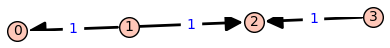

In [43]:
M=graphMagma([('K',2),('N',2),('K',2)])
GM=GraphMagmaAlg(QQ,M)
R = GM.magma_algebra
GM.quiver.show(edge_labels=True)


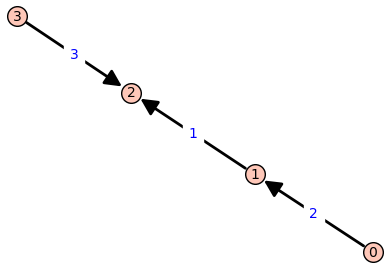

In [44]:
M2=graphMagma([('N',3),('N',2),('K',4)])
GM2=GraphMagmaAlg(QQ,M2)
GM2.quiver.show(edge_labels=True)

In [45]:
GM.getDecomposition()

[a_0_0, -a_0_0 + a_1_0, -a_1_0 + a_2_0, 1 - a_2_0]

In [46]:
P1=GM.Indecomposable_Projective(1);P1

GraphMagmaModule over Free algebra quotient on 6 generators ('a_0_0', 'a_0_1', 'a_1_0', 'a_1_1', 'a_2_0', 'a_2_1') and dimension 7 over Rational Field with dimension 3
Basis: [(1, 0, 0), (0, 1, 0), (0, 0, 1)]

In [47]:
P1.vector_space.basis()

[
(1, 0, 0),
(0, 1, 0),
(0, 0, 1)
]

In [48]:
GM.getMultiplicationTable()

Multiplication table of the algebra on the module:

      | a_0_0 a_0_1 a_1_0 a_1_1 a_2_0 a_2_1 
------- ----- ----- ----- ----- ----- ----- 
a_0_0 | a_0_0 a_0_0 a_0_0 a_0_0 a_0_0 a_0_0 
a_0_1 | a_0_1 a_0_1 a_0_1 a_0_1 a_0_1 a_0_1 
a_1_0 | a_0_0 a_0_1 a_1_0 a_1_1 a_1_0 a_1_0 
a_1_1 | a_0_0 a_0_1 a_1_0 a_1_1 a_1_1 a_1_1 
a_2_0 | a_0_0 a_0_1 a_1_0 a_1_1 a_2_0 a_2_0 
a_2_1 | a_0_0 a_0_1 a_1_0 a_1_1 a_2_1 a_2_1 


In [49]:
GM.simple_left_ideals

[[-a_0_0 + a_0_1],
 [-a_0_0 + a_1_0],
 [-a_1_0 + a_1_1, a_2_0 - a_2_1],
 [1 - a_2_0]]

In [50]:
GM.simple_right_ideals

[[a_0_0], [-a_0_0 + a_0_1, a_1_0 - a_1_1], [-a_1_0 + a_2_0], [-a_2_0 + a_2_1]]

## Define a module structure on GM

In [51]:
GM.getLocalProjectiveBasis(0)

[a_0_0]

In [52]:
# The indecomposable projective right module of index 2
P2 = GM.Indecomposable_Projective(2)
P2.getMultiplicationTable()

Scalar multiplication table on the module with basis v0:

      |        v0 
-------   ------- 
a_0_0 |         0 
a_0_1 |         0 
a_1_0 |         0 
a_1_1 |         0 
a_2_0 |        v0 
a_2_1 |        v0 


In [53]:
# The indecomposable injective left module of index 1
I1=P1.dualize();I1.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2:

      |        v0        v1        v2 
-------   -------   -------   ------- 
a_0_0 |         0        v1         0 
a_0_1 |         0     v0+v1         0 
a_1_0 |        v0        v1         0 
a_1_1 |        v0        v1       -v0 
a_2_0 |        v0        v1        v2 
a_2_1 |        v0        v1        v2 


In [54]:
# Define a submodule of the indecomposable injective left module I(1)
N=I1.submodule([I1.vector_space([0,-5,0])])
N.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1:

      |        v0        v1 
-------   -------   ------- 
a_0_0 |         0        v1 
a_0_1 |         0     v0+v1 
a_1_0 |        v0        v1 
a_1_1 |        v0        v1 
a_2_0 |        v0        v1 
a_2_1 |        v0        v1 


In [55]:
# Query the endomorphism ring of N
N.Endomorphism_Ring();

The endomorphism ring of the module is isomorphic to a subalgebra of the algebra of matrices of size  2 x 2  consisting of the matrices of the form:



<IPython.core.display.Math object>

where  (r5,)  is/are element(s) of the Rational Field. 
 



In [56]:
# Check if N is indecomposable
N.is_Indecomposable()

True

In [57]:
I12=I1.direct_sum(I1)

In [58]:
I12.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |        v0        v1        v2        v3        v4        v5 
-------   -------   -------   -------   -------   -------   ------- 
a_0_0 |         0        v1         0         0        v4         0 
a_0_1 |         0     v0+v1         0         0     v3+v4         0 
a_1_0 |        v0        v1         0        v3        v4         0 
a_1_1 |        v0        v1       -v0        v3        v4       -v3 
a_2_0 |        v0        v1        v2        v3        v4        v5 
a_2_1 |        v0        v1        v2        v3        v4        v5 


In [59]:
K=I12.submodule([I12.vector_space([1,-1,1,1,1,1]),I12.vector_space([0,0,0,0,0,0])])
K.is_Indecomposable(reason=True)

The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r7 == 0, r8 == 0],
[r7 == 1, r8 == 1],
[r7 == (1/2), r8 == 0],
[r7 == (1/2), r8 == 1]
] .
 



In [60]:
K.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3:

      |         v0         v1         v2         v3 
-------   --------   --------   --------   -------- 
a_0_0 |          0         v1          0          0 
a_0_1 |          0   v0+v1-v3          0          0 
a_1_0 |         v0         v1          0         v3 
a_1_1 |         v0         v1     -v0-v3         v3 
a_2_0 |         v0         v1         v2         v3 
a_2_1 |         v0         v1         v2         v3 


# Classifications of Indecomposable Injective Left Modules I(i)

## 1<i<n

### KK: The case when (u_i,u_{i+1})=(K_p,K_q)

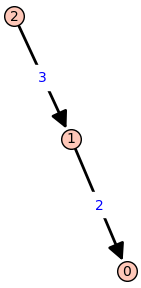

In [61]:
GMA_KK=GraphMagmaAlg(QQ,graphMagma([('K',3),('K',4)]))
R_KK=GMA_KK.magma_algebra
GMA_KK.quiver.show(edge_labels=True,figsize=(3,3))

In [62]:
P1_KK=GMA_KK.Indecomposable_Projective(1)
I1_KK=P1_KK.dualize()
I1_KK.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2:

      |        v0        v1        v2 
-------   -------   -------   ------- 
a_0_0 |         0        v1        v2 
a_0_1 |         0     v0+v1        v2 
a_0_2 |         0        v1     v0+v2 
a_1_0 |        v0        v1        v2 
a_1_1 |        v0        v1        v2 
a_1_2 |        v0        v1        v2 
a_1_3 |        v0        v1        v2 


#### A Case Study

In [74]:
D=I1_KK.direct_sum(I1_KK)
D.submodule([D.vector_space([1,0,0,0,0,0]),D.vector_space([0,0,1,0,0,0]),D.vector_space([0,1,1,0,1,1])]).getMultiplicationTable()
D.is_Indecomposable(reason=True)

Scalar multiplication table on the module with basis v0,v1,v2,v3:

      |         v0         v1         v2         v3 
-------   --------   --------   --------   -------- 
a_0_0 |          0         v1         v2          0 
a_0_1 |          0   v0+v1+v3         v2          0 
a_0_2 |          0      v1+v3      v0+v2          0 
a_1_0 |         v0         v1         v2         v3 
a_1_1 |         v0         v1         v2         v3 
a_1_2 |         v0         v1         v2         v3 
a_1_3 |         v0         v1         v2         v3 
The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r19 == -1/2*sqrt(-4*r23*r24 + 1) + 1/2, r20 == r23, r21 == 1/2*sqrt(-4*r23*r24 + 1) + 1/2, r22 == r24],
[r19 == 1/2*sqrt(-4*r25*r26 + 1) + 1/2, r20 == r25, r21 == -1/2*sqrt(-4*r25*r26 + 1) + 1/2, r22 == r26],
[r19 == 0, r20 == 0, r21 == 1, r22 == r27],
[r19 == 1, r20 == 0, r21 == 0, r22 == r28],
[r19 == 1, r20 == 0, r21 == 1, r22 == 0],
[r19 == 0, r20 == 0, r21 == 0, r22 == 0]
] .
 



### KN: The case when (u_i,u_{i+1})=(K_p,N_q)

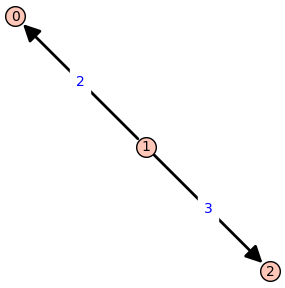

In [63]:
GMA_KN=GraphMagmaAlg(QQ,graphMagma([('K',3),('N',4)]))
R_KN=GMA_KN.magma_algebra
GMA_KN.quiver.show(edge_labels=True,figsize=(3,3))

In [64]:
P1_KN=GMA_KN.Indecomposable_Projective(1)
I1_KN=P1_KN.dualize()
I1_KN.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |        v0        v1        v2        v3        v4        v5 
-------   -------   -------   -------   -------   -------   ------- 
a_0_0 |         0        v1        v2         0         0         0 
a_0_1 |         0     v0+v1        v2         0         0         0 
a_0_2 |         0        v1     v0+v2         0         0         0 
a_1_0 |        v0        v1        v2         0         0         0 
a_1_1 |        v0        v1        v2       -v0         0         0 
a_1_2 |        v0        v1        v2         0       -v0         0 
a_1_3 |        v0        v1        v2         0         0       -v0 


### NK: The case when (u_i,u_{i+1})=(N_p,K_q)

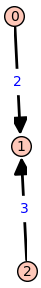

In [65]:
GMA_NK=GraphMagmaAlg(QQ,graphMagma([('N',3),('K',4)]))
R_NK=GMA_NK.magma_algebra
GMA_NK.quiver.show(edge_labels=True,figsize=(3,3))

In [66]:
P1_NK=GMA_NK.Indecomposable_Projective(1)
I1_NK=P1_NK.dualize()
I1_NK.getMultiplicationTable()

Scalar multiplication table on the module with basis v0:

      |        v0 
-------   ------- 
a_0_0 |         0 
a_0_1 |         0 
a_0_2 |         0 
a_1_0 |        v0 
a_1_1 |        v0 
a_1_2 |        v0 
a_1_3 |        v0 


### NN: The case when (u_i,u_{i+1})=(N_p,N_q)

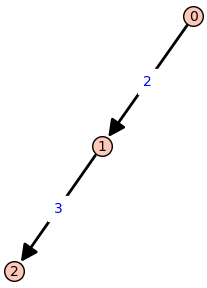

In [67]:
GMA_NN=GraphMagmaAlg(QQ,graphMagma([('N',3),('N',4)]))
R_NN=GMA_NN.magma_algebra
GMA_NN.quiver.show(edge_labels=True,figsize=(3,3))

In [68]:
P1_NN=GMA_NN.Indecomposable_Projective(1)
I1_NN=P1_NN.dualize()
I1_NN.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3:

      |        v0        v1        v2        v3 
-------   -------   -------   -------   ------- 
a_0_0 |         0         0         0         0 
a_0_1 |         0         0         0         0 
a_0_2 |         0         0         0         0 
a_1_0 |        v0         0         0         0 
a_1_1 |        v0       -v0         0         0 
a_1_2 |        v0         0       -v0         0 
a_1_3 |        v0         0         0       -v0 
